In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [10]:
#Import the dataset
data = pd.read_csv(r"C:\Users\USER PC\Downloads\archive (9)\air-traffic-landings-statistics.csv")

In [6]:
data.head()

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Landing Aircraft Type,Aircraft Body Type,Aircraft Manufacturer,Aircraft Model,Aircraft Version,Landing Count,Total Landed Weight
0,201809,SkyWest Airlines,OO,United Airlines,UA,International,Canada,Passenger,Regional Jet,Bombardier,CRJ2,-,30,1410000
1,201809,Air Canada,AC,Air Canada,AC,International,Canada,Passenger,Narrow Body,Airbus,A320,-,125,17787978
2,201809,Japan Airlines,JL,Japan Airlines,JL,International,Asia,Passenger,Wide Body,Boeing,B773,-,30,16620000
3,201809,"COPA Airlines, Inc.",CM,"COPA Airlines, Inc.",CM,International,Central America,Passenger,Narrow Body,Boeing,B739,-,3,491700
4,201809,Hong Kong Airlines Limited,HX,Hong Kong Airlines Limited,HX,International,Asia,Passenger,Wide Body,Airbus,A359,-,16,7301712


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22047 entries, 0 to 22046
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Activity Period              22047 non-null  int64 
 1   Operating Airline            22047 non-null  object
 2   Operating Airline IATA Code  21972 non-null  object
 3   Published Airline            22047 non-null  object
 4   Published Airline IATA Code  21972 non-null  object
 5   GEO Summary                  22047 non-null  object
 6   GEO Region                   22047 non-null  object
 7   Landing Aircraft Type        22047 non-null  object
 8   Aircraft Body Type           22047 non-null  object
 9   Aircraft Manufacturer        22036 non-null  object
 10  Aircraft Model               22047 non-null  object
 11  Aircraft Version             20889 non-null  object
 12  Landing Count                22047 non-null  int64 
 13  Total Landed Weight          22

In [10]:
data.isnull()

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Landing Aircraft Type,Aircraft Body Type,Aircraft Manufacturer,Aircraft Model,Aircraft Version,Landing Count,Total Landed Weight
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22042,False,False,False,False,False,False,False,False,False,False,False,False,False,False
22043,False,False,False,False,False,False,False,False,False,False,False,False,False,False
22044,False,False,False,False,False,False,False,False,False,False,False,False,False,False
22045,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
data.isnull().sum()

Activity Period                   0
Operating Airline                 0
Operating Airline IATA Code      75
Published Airline                 0
Published Airline IATA Code      75
GEO Summary                       0
GEO Region                        0
Landing Aircraft Type             0
Aircraft Body Type                0
Aircraft Manufacturer            11
Aircraft Model                    0
Aircraft Version               1158
Landing Count                     0
Total Landed Weight               0
dtype: int64

In [18]:
# The missing values oes not matter much to the analysis, so I wil drop it.
data = data.dropna()

In [20]:
data.isnull().sum()

Activity Period                0
Operating Airline              0
Operating Airline IATA Code    0
Published Airline              0
Published Airline IATA Code    0
GEO Summary                    0
GEO Region                     0
Landing Aircraft Type          0
Aircraft Body Type             0
Aircraft Manufacturer          0
Aircraft Model                 0
Aircraft Version               0
Landing Count                  0
Total Landed Weight            0
dtype: int64

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20814 entries, 0 to 22046
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Activity Period              20814 non-null  int64 
 1   Operating Airline            20814 non-null  object
 2   Operating Airline IATA Code  20814 non-null  object
 3   Published Airline            20814 non-null  object
 4   Published Airline IATA Code  20814 non-null  object
 5   GEO Summary                  20814 non-null  object
 6   GEO Region                   20814 non-null  object
 7   Landing Aircraft Type        20814 non-null  object
 8   Aircraft Body Type           20814 non-null  object
 9   Aircraft Manufacturer        20814 non-null  object
 10  Aircraft Model               20814 non-null  object
 11  Aircraft Version             20814 non-null  object
 12  Landing Count                20814 non-null  int64 
 13  Total Landed Weight          20814 n

In [24]:
data.columns

Index(['Activity Period', 'Operating Airline', 'Operating Airline IATA Code',
       'Published Airline', 'Published Airline IATA Code', 'GEO Summary',
       'GEO Region', 'Landing Aircraft Type', 'Aircraft Body Type',
       'Aircraft Manufacturer', 'Aircraft Model', 'Aircraft Version',
       'Landing Count', 'Total Landed Weight'],
      dtype='object')

In [26]:
#Checking for duplicate columns
data.columns.duplicated().any()

False

In [29]:
#Inserting underscore(_) inbetween the columns names
data.columns = data.columns.str.replace(' ','_')

In [31]:
data.columns

Index(['Activity_Period', 'Operating_Airline', 'Operating_Airline_IATA_Code',
       'Published_Airline', 'Published_Airline_IATA_Code', 'GEO_Summary',
       'GEO_Region', 'Landing_Aircraft_Type', 'Aircraft_Body_Type',
       'Aircraft_Manufacturer', 'Aircraft_Model', 'Aircraft_Version',
       'Landing_Count', 'Total_Landed_Weight'],
      dtype='object')

## Time-Series Analysis

In [34]:
# Coverting "Activity_Period" into a real datetime
data['Activity_Period'].head()

0    201809
1    201809
2    201809
3    201809
4    201809
Name: Activity_Period, dtype: int64

In [42]:
data['Activity_Period']=pd.to_datetime(data['Activity_Period'], format='%Y%m')

In [44]:
daat=data.set_index('Activity_Period')

In [56]:
data['Activity_Period'] = pd.to_datetime(data['Activity_Period'], format='%Y%m', errors='raise')
data['Activity_Period'].head()
data['Activity_Period'].dtype

dtype('<M8[ns]')

In [60]:
data = data.set_index('Activity_Period')

In [62]:
data.index

DatetimeIndex(['2018-09-01', '2018-09-01', '2018-09-01', '2018-09-01',
               '2018-09-01', '2018-09-01', '2018-09-01', '2018-09-01',
               '2018-09-01', '2018-09-01',
               ...
               '2005-07-01', '2005-07-01', '2005-07-01', '2005-07-01',
               '2005-07-01', '2005-07-01', '2005-07-01', '2005-07-01',
               '2005-07-01', '2005-07-01'],
              dtype='datetime64[ns]', name='Activity_Period', length=20814, freq=None)

In [68]:
#Creating a Monthly landing Series
# Total landing per month
monthly_landings = data['Landing_Count'].resample('ME').sum()
monthly_landings

Activity_Period
2005-07-31    10803
2005-08-31    10822
2005-09-30    10292
2005-10-31    10296
2005-11-30     9466
              ...  
2018-05-31    18617
2018-06-30    19071
2018-07-31    19682
2018-08-31    19876
2018-09-30    17813
Freq: ME, Name: Landing_Count, Length: 159, dtype: int64

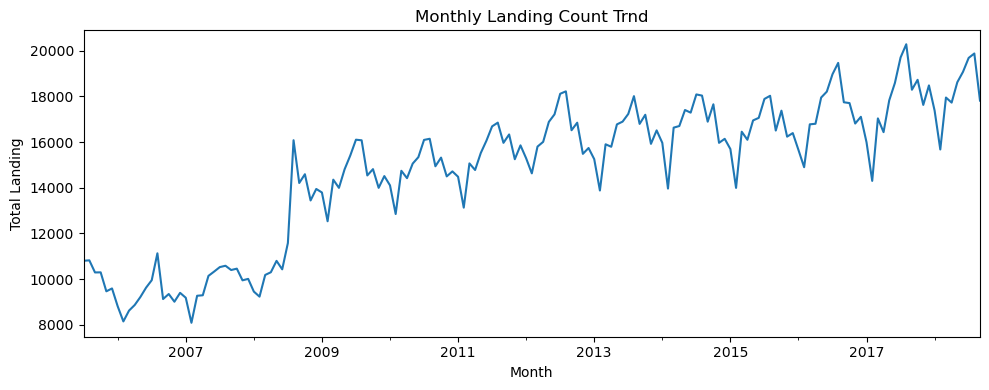

In [72]:
#Plotting the monthly trend
monthly_landings.plot(figsize=(10 , 4))
plt.title("Monthly Landing Count Trnd")
plt.xlabel("Month")
plt.ylabel("Total Landing")
plt.tight_layout()
plt.show()

In [76]:
yearly_landings = data['Landing_Count'].resample('YE').sum()
yearly_landings

Activity_Period
2005-12-31     61271
2006-12-31    111256
2007-12-31    118232
2008-12-31    144244
2009-12-31    174929
2010-12-31    178215
2011-12-31    185965
2012-12-31    196737
2013-12-31    196150
2014-12-31    200713
2015-12-31    198656
2016-12-31    208074
2017-12-31    213264
2018-12-31    163783
Freq: YE-DEC, Name: Landing_Count, dtype: int64

In [78]:
#Seasonal monthly pattern
data['Month'] = data.index.month
data.groupby('Month')['Landing_Count'].sum()

Month
1     181034
2     165318
3     188777
4     187211
5     197936
6     201508
7     221408
8     229589
9     210015
10    196653
11    183647
12    188393
Name: Landing_Count, dtype: int64

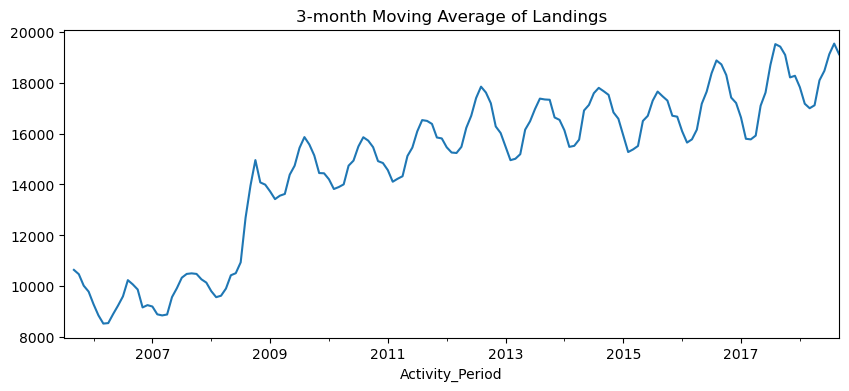

In [80]:
monthly_landings.rolling(window=3).mean().plot(figsize=(10,4))
plt.title("3-month Moving Average of Landings")
plt.show()

## Airline-Level Analysis

In [85]:
data.columns

Index(['Operating_Airline', 'Operating_Airline_IATA_Code', 'Published_Airline',
       'Published_Airline_IATA_Code', 'GEO_Summary', 'GEO_Region',
       'Landing_Aircraft_Type', 'Aircraft_Body_Type', 'Aircraft_Manufacturer',
       'Aircraft_Model', 'Aircraft_Version', 'Landing_Count',
       'Total_Landed_Weight', 'Month'],
      dtype='object')

In [93]:
# Top Airlne by Landing Count
data.groupby('Operating_Airline')['Landing_Count'].sum().sort_values(ascending=False)

Operating_Airline
SkyWest Airlines                    551300
United Airlines                     383684
United Airlines - Pre 07/01/2013    325578
Southwest Airlines                  163882
Virgin America                      153791
                                     ...  
BelAir Airlines                         33
Evergreen International Airlines        31
United Parcel Service Co                27
Miami Air International                 11
Xtra Airways                             1
Name: Landing_Count, Length: 95, dtype: int64

In [95]:
#Top Airlines by Total landed by Weight
data.groupby('Operating_Airline')['Total_Landed_Weight'].sum().sort_values(ascending=False)

Operating_Airline
United Airlines                     74729447498
United Airlines - Pre 07/01/2013    69808502544
American Airlines                   26602024269
SkyWest Airlines                    25544034937
Virgin America                      21761816485
                                       ...     
United Parcel Service Co                7526000
Redding Aero Enterprises                4775350
Air Canada Jazz                         2693000
Miami Air International                 1573968
Xtra Airways                             124000
Name: Total_Landed_Weight, Length: 95, dtype: int64

In [101]:
#Average Weight per Landing (Airline Efficiency Metric)
data.groupby('Operating_Airline').apply(
    lambda x: x['Total_Landed_Weight'].sum() / x['Landing_Count'].sum()
).sort_values(ascending=False)

C:\Users\USER PC\AppData\Local\Temp\ipykernel_8076\4123600536.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data.groupby('Operating_Airline').apply(


Operating_Airline
Nippon Cargo Airlines        680232.335049
Emirates                     673785.303541
Cargolux Airlines            666000.000000
Lufthansa German Airlines    653944.819253
British Airways              648873.303180
                                 ...      
ExpressJet Airlines           43556.909925
American Eagle Airlines       41254.686097
Air Cargo Carriers            26000.000000
Ameriflight                   13606.925051
Redding Aero Enterprises       8497.064057
Length: 95, dtype: float64

In [105]:
#Domestic vs International Airline Focus
data.groupby(['Operating_Airline' , 'GEO_Summary'])['Landing_Count'].sum()

Operating_Airline                         GEO_Summary  
ABC Aerolineas S.A. de C.V. dba Interjet  International     173
ABX Air                                   Domestic         5061
ATA Airlines                              Domestic         1386
                                          International       4
Aer Lingus                                International    1883
                                                           ... 
WestJet Airlines                          International    3681
World Airways                             Domestic          190
                                          International       2
XL Airways France                         International     238
Xtra Airways                              Domestic            1
Name: Landing_Count, Length: 114, dtype: int64

In [107]:
#Aircraft Usage per Airline(Which aircraftis mostly used by the airlines)
data.groupby(['Operating_Airline' , 'Aircraft_Model'])['Landing_Count'].sum()

Operating_Airline                         Aircraft_Model
ABC Aerolineas S.A. de C.V. dba Interjet  A320               173
ABX Air                                   767               4188
                                          B762                 1
                                          B763                 1
                                          DC-8                 7
                                                            ... 
XL Airways France                         777                  2
                                          A330               117
                                          A332               102
                                          A333                17
Xtra Airways                              737                  1
Name: Landing_Count, Length: 409, dtype: int64

In [109]:
#Monthly Trends per Airline
data.groupby(['Operating_Airline' , data.index])['Landing_Count'].sum().unstack(0)

Operating_Airline,ABC Aerolineas S.A. de C.V. dba Interjet,ABX Air,ATA Airlines,Aer Lingus,Aeromexico,Air Berlin,Air Canada,Air Canada Jazz,Air Cargo Carriers,Air China,...,United Airlines - Pre 07/01/2013,United Parcel Service Co,Virgin America,Virgin Atlantic,Volaris Airlines,WOW Air,WestJet Airlines,World Airways,XL Airways France,Xtra Airways
Activity_Period,,,,,,,,,,,,,,,,,,,,,
2005-07-01,NaN,41.0,169.0,NaN,NaN,NaN,309.0,NaN,NaN,23.0,...,3013.0,NaN,NaN,31.0,NaN,NaN,22.0,NaN,NaN,NaN
2005-08-01,NaN,45.0,163.0,NaN,NaN,NaN,303.0,NaN,NaN,16.0,...,3020.0,NaN,NaN,31.0,NaN,NaN,22.0,NaN,NaN,NaN
2005-09-01,NaN,42.0,129.0,NaN,NaN,NaN,231.0,NaN,NaN,18.0,...,2935.0,NaN,NaN,30.0,NaN,NaN,22.0,NaN,NaN,NaN
2005-10-01,NaN,34.0,143.0,NaN,NaN,NaN,215.0,NaN,NaN,17.0,...,3065.0,NaN,NaN,31.0,NaN,NaN,17.0,NaN,NaN,NaN
2005-11-01,NaN,8.0,146.0,NaN,NaN,NaN,180.0,NaN,NaN,17.0,...,2723.0,NaN,NaN,30.0,NaN,NaN,17.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-05-01,28.0,NaN,NaN,31.0,88.0,NaN,270.0,NaN,NaN,31.0,...,NaN,NaN,NaN,67.0,17.0,26.0,83.0,NaN,NaN,NaN
2018-06-01,26.0,NaN,NaN,30.0,90.0,NaN,340.0,NaN,NaN,30.0,...,NaN,NaN,NaN,73.0,18.0,30.0,90.0,NaN,4.0,NaN
2018-07-01,27.0,NaN,NaN,31.0,92.0,NaN,368.0,NaN,NaN,31.0,...,NaN,NaN,NaN,76.0,21.0,31.0,94.0,NaN,13.0,NaN


In [111]:
#Airline Share of Total Traffic
(data.groupby('Operating_Airline')['Landing_Count'].sum() / 
 data['Landing_Count'].sum()) * 100

Operating_Airline
ABC Aerolineas S.A. de C.V. dba Interjet    0.007357
ABX Air                                     0.215225
ATA Airlines                                0.059111
Aer Lingus                                  0.080077
Aeromexico                                  0.311845
                                              ...   
WOW Air                                     0.025686
WestJet Airlines                            0.156539
World Airways                               0.008165
XL Airways France                           0.010121
Xtra Airways                                0.000043
Name: Landing_Count, Length: 95, dtype: float64

In [115]:
#Detect Weird or Suspicious Patterns(Airlines with extremely high landed weight but few flights)
data.groupby('Operating_Airline')[['Landing_Count' , 'Total_Landed_Weight']].sum()

,Landing_Count,Total_Landed_Weight
Operating_Airline,,
ABC Aerolineas S.A. de C.V. dba Interjet,173,24676315
ABX Air,5061,1241599000
ATA Airlines,1390,252071500
Aer Lingus,1883,752968844
Aeromexico,7333,987193600
...,...,...
WOW Air,604,243908486
WestJet Airlines,3681,494567010
World Airways,192,121692000


## Top Aircraft Types by Landing Count

In [118]:
data.columns

Index(['Operating_Airline', 'Operating_Airline_IATA_Code', 'Published_Airline',
       'Published_Airline_IATA_Code', 'GEO_Summary', 'GEO_Region',
       'Landing_Aircraft_Type', 'Aircraft_Body_Type', 'Aircraft_Manufacturer',
       'Aircraft_Model', 'Aircraft_Version', 'Landing_Count',
       'Total_Landed_Weight', 'Month'],
      dtype='object')

In [122]:
#Group by Aircraft Model and Sum the Landing Counts
landing_counts = (
    data.groupby('Aircraft_Model')["Landing_Count"]
        .sum()
        .sort_values(ascending=False)
)
landing_counts

Aircraft_Model
737     404520
A320    365929
A319    166034
757     151547
CRJ     135400
         ...  
B777         3
764          2
B735         2
C402         1
35A          1
Name: Landing_Count, Length: 80, dtype: int64

In [126]:
#Showing top Aircraft Types
top_models = landing_counts.head(15)
top_models

Aircraft_Model
737      404520
A320     365929
A319     166034
757      151547
CRJ      135400
EMB      134743
ERJ      122083
CL600    113528
747       81276
767       72685
A321      69632
B738      68136
777       62658
B739      55675
E170      53656
Name: Landing_Count, dtype: int64

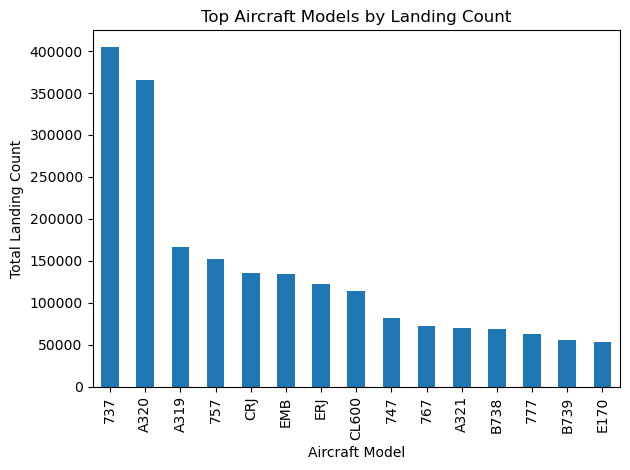

In [130]:
top_models.plot(kind="bar")
plt.xlabel("Aircraft Model")
plt.ylabel("Total Landing Count")
plt.title("Top Aircraft Models by Landing Count")
plt.tight_layout()
plt.show()

In [132]:
#Total landings by Aircraft Manufacturer
manufacturer_trends = (
    data.groupby("Aircraft_Manufacturer")["Landing_Count"]
        .sum()
        .sort_values(ascending=False)
)
manufacturer_trends

Aircraft_Manufacturer
Boeing               1045008
Airbus                636996
Embraer               313167
Bombardier            303389
McDonnell Douglas      43656
DeHavilland             3281
Beechcraft              2293
Fairchild               1489
Shorts                  1447
Cessna                   562
Swearingen               179
Piper                     12
Lockheed                   9
LearJet                    1
Name: Landing_Count, dtype: int64

In [138]:
#Manufacturer Share (%)
manufacturer_share = (
    manufacturer_trends / manufacturer_trends.sum() * 100
).round(2)
manufacturer_share

Aircraft_Manufacturer
Boeing               44.44
Airbus               27.09
Embraer              13.32
Bombardier           12.90
McDonnell Douglas     1.86
DeHavilland           0.14
Beechcraft            0.10
Fairchild             0.06
Shorts                0.06
Cessna                0.02
Swearingen            0.01
Piper                 0.00
Lockheed              0.00
LearJet               0.00
Name: Landing_Count, dtype: float64

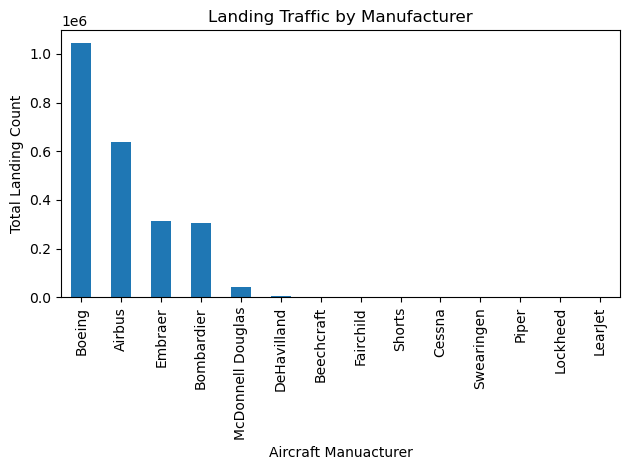

In [140]:
#Bar Chat Visualization of Manufacturer
manufacturer_trends.plot(kind="bar")
plt.xlabel("Aircraft Manuacturer")
plt.ylabel("Total Landing Count")
plt.title("Landing Traffic by Manufacturer")
plt.tight_layout()
plt.show()

In [146]:
# Total Landed Weight by Aircraft Model
weight_by_model = (
    data.groupby("Aircraft_Model")["Total_Landed_Weight"]
        .sum()
        .sort_values(ascending=False)
)
weight_by_model

Aircraft_Model
737      54171683938
A320     52070811042
747      51750763868
777      30857703069
757      30545132000
            ...     
MD83          390000
B735          220000
PA-31          81500
35A            15300
C402            6850
Name: Total_Landed_Weight, Length: 80, dtype: int64

In [150]:
# Total Landed Weight by Manufacturer
weight_by_manufacturer = (
    data.groupby("Aircraft_Manufacturer")["Total_Landed_Weight"]
        .sum()
        .sort_values(ascending=False)
)
weight_by_manufacturer

Aircraft_Manufacturer
Boeing               251817325635
Airbus               104165989444
Bombardier            17039039085
Embraer               13254039099
McDonnell Douglas      6924973922
DeHavilland             202601750
Shorts                   37622000
Beechcraft               30624280
Fairchild                20846000
Cessna                    4775350
Lockheed                  3312000
Swearingen                2484460
Piper                       81500
LearJet                     15300
Name: Total_Landed_Weight, dtype: int64

In [154]:
# Weight Share by Percentage(%)
weight_share = (
    weight_by_manufacturer / weight_by_manufacturer.sum() * 100
).round(2)
weight_share

Aircraft_Manufacturer
Boeing               63.99
Airbus               26.47
Bombardier            4.33
Embraer               3.37
McDonnell Douglas     1.76
DeHavilland           0.05
Shorts                0.01
Beechcraft            0.01
Fairchild             0.01
Cessna                0.00
Lockheed              0.00
Swearingen            0.00
Piper                 0.00
LearJet               0.00
Name: Total_Landed_Weight, dtype: float64

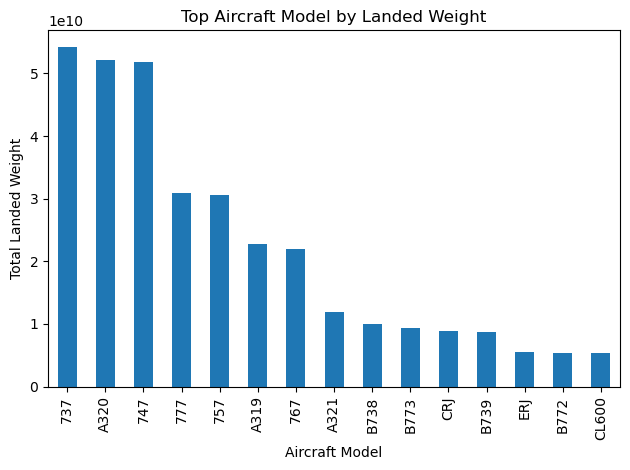

In [156]:
# Bar Chart Visualization of Weight

weight_by_model.head(15).plot(kind="bar")
plt.xlabel("Aircraft Model")
plt.ylabel("Total Landed Weight")
plt.title("Top Aircraft Model by Landed Weight")
plt.tight_layout()
plt.show()

## Airline x Aircraft Type Matrix

In [166]:
matrix = data.pivot_table(
    index = "Operating_Airline",
    columns = "Aircraft_Model",
    values = "Landing_Count",
    aggfunc = "sum",
    fill_value = 0
)
matrix

Aircraft_Model,1900C,35A,717,727,737,747,757,764,767,777,...,MD-11,MD-80,MD-88,MD-90,MD11,MD83,MD90,PA-31,SA-227,SD3
Operating_Airline,,,,,,,,,,,,,,,,,,,,,
ABC Aerolineas S.A. de C.V. dba Interjet,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ABX Air,0,0,0,0,0,0,0,0,4188,0,...,0,0,0,0,0,0,0,0,0,0
ATA Airlines,0,0,0,0,765,0,616,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Aer Lingus,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Aeromexico,0,0,0,0,4365,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WOW Air,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
WestJet Airlines,0,0,0,0,2368,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
World Airways,0,0,0,0,0,189,0,0,0,0,...,3,0,0,0,0,0,0,0,0,0


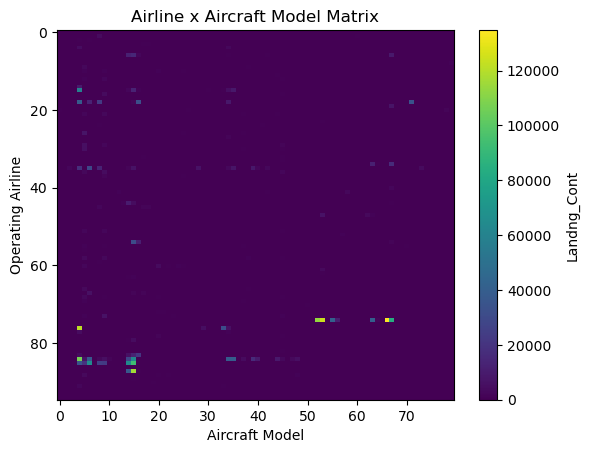

In [168]:
# Heatmap
plt.imshow(matrix, aspect='auto')
plt.colorbar(label = "Landng_Cont")
plt.xlabel("Aircraft Model")
plt.ylabel("Operating Airline")
plt.title("Airline x Aircraft Model Matrix")
plt.show()

In [176]:
matrix_manufacturer = data.pivot_table(
    index="Operating_Airline",
    columns="Aircraft_Manufacturer",
    values="Landing_Count",
    aggfunc="sum",
    fill_value=0
)
matrix_manufacturer

Aircraft_Manufacturer,Airbus,Beechcraft,Boeing,Bombardier,Cessna,DeHavilland,Embraer,Fairchild,LearJet,Lockheed,McDonnell Douglas,Piper,Shorts,Swearingen
Operating_Airline,,,,,,,,,,,,,,
ABC Aerolineas S.A. de C.V. dba Interjet,173,0,0,0,0,0,0,0,0,0,0,0,0,0
ABX Air,0,0,4190,0,0,0,0,0,0,0,871,0,0,0
ATA Airlines,0,0,1381,0,0,0,0,0,0,9,0,0,0,0
Aer Lingus,1883,0,0,0,0,0,0,0,0,0,0,0,0,0
Aeromexico,0,0,7296,0,0,0,37,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WOW Air,603,0,1,0,0,0,0,0,0,0,0,0,0,0
WestJet Airlines,0,0,3681,0,0,0,0,0,0,0,0,0,0,0
World Airways,0,0,189,0,0,0,0,0,0,0,3,0,0,0


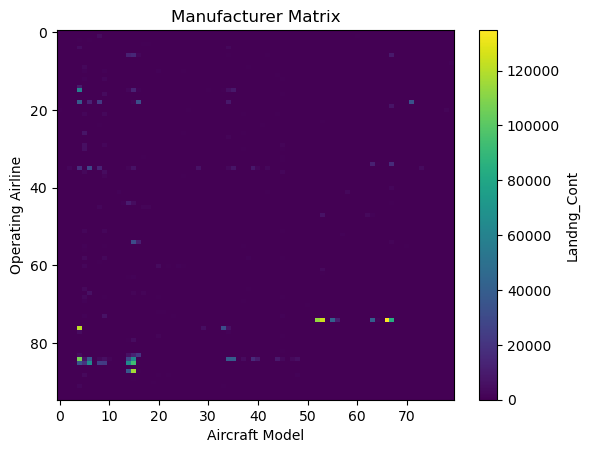

In [178]:
# Heatmap
plt.imshow(matrix, aspect='auto')
plt.colorbar(label = "Landng_Cont")
plt.xlabel("Aircraft Model")
plt.ylabel("Operating Airline")
plt.title("Manufacturer Matrix")
plt.show()

## GEO Region Pattern

In [187]:
#Aircraft TYpes by GEO Region (Landing Count)
region_aircraft = (
    data.groupby(["GEO_Region","Aircraft_Model"])["Landing_Count"]
    .sum()
    .reset_index()
    .sort_values(["GEO_Region","Landing_Count"], ascending=[True,False])
)
region_aircraft #This tells you which aircraft dominate Asia, Canada, Europe, Central America

,GEO_Region,Aircraft_Model,Landing_Count
1,Asia,747,51021
4,Asia,777,36849
17,Asia,B773,12950
14,Asia,B744,4165
19,Asia,B789,3450
...,...,...,...
157,US,B777,3
185,US,MD83,3
144,US,B735,2
121,US,35A,1


In [193]:
# GEO Summary(Domestic vs International) x Aircrft Model
geo_summary_aircraft = (
    data.groupby(["GEO_Region","Aircraft_Model"])["Landing_Count"]
    .sum()
    .reset_index()
    .sort_values(["GEO_Region","Landing_Count"], ascending=[True,False])
)
geo_summary_aircraft

,GEO_Region,Aircraft_Model,Landing_Count
1,Asia,747,51021
4,Asia,777,36849
17,Asia,B773,12950
14,Asia,B744,4165
19,Asia,B789,3450
...,...,...,...
157,US,B777,3
185,US,MD83,3
144,US,B735,2
121,US,35A,1


In [199]:
#Region x Aircraft Model Pivot Matrx
region_matrix = data.pivot_table(
    index="GEO_Region",
    columns="Aircraft_Model",
    values="Landing_Count",
    aggfunc="sum",
    fill_value=0
)
region_matrix

Aircraft_Model,1900C,35A,717,727,737,747,757,764,767,777,...,MD-11,MD-80,MD-88,MD-90,MD11,MD83,MD90,PA-31,SA-227,SD3
GEO_Region,,,,,,,,,,,,,,,,,,,,,
Asia,0,0,0,0,18,51021,0,2,1188,36849,...,95,0,0,0,1,0,0,0,0,0
Australia / Oceania,0,0,0,0,0,5528,0,0,0,3083,...,0,0,0,0,0,0,0,0,0,0
Canada,0,0,0,1,11613,1,141,0,505,1,...,0,0,0,0,0,0,0,0,0,0
Caribbean,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Central America,0,0,0,0,166,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Europe,0,0,0,0,0,22504,0,0,1248,8933,...,691,0,0,0,0,0,0,0,0,0
Mexico,0,0,0,91,16294,0,90,0,5,0,...,0,63,0,0,0,0,0,0,0,0
Middle East,0,0,0,0,0,0,0,0,0,2568,...,0,0,0,0,0,0,0,0,0,0
South America,0,0,0,0,0,2,0,0,684,0,...,0,0,0,0,0,0,0,0,0,0


In [207]:
#Region x Manufacturer(does Asia lean more towards Airbus wide-bodies? Is North Amrica saturated with Embraer and Bombardier)
region_manufacturer = data.pivot_table(
    index="GEO_Region",
    columns="Aircraft_Manufacturer",
    values="Landing_Count",
    aggfunc="sum",
    fill_value=0
) 
region_manufacturer

Aircraft_Manufacturer,Airbus,Beechcraft,Boeing,Bombardier,Cessna,DeHavilland,Embraer,Fairchild,LearJet,Lockheed,McDonnell Douglas,Piper,Shorts,Swearingen
GEO_Region,,,,,,,,,,,,,,
Asia,6959,0,118570,0,0,0,0,0,0,0,96,0,0,0
Australia / Oceania,250,0,11630,0,0,0,0,0,0,0,0,0,0,0
Canada,41686,0,17558,26018,0,0,12198,0,0,0,0,0,0,0
Caribbean,1,0,2,0,0,0,0,0,0,0,0,0,0,0
Central America,5429,0,1836,0,0,0,0,0,0,0,0,0,0,0
Europe,19771,0,42821,0,0,0,0,0,0,0,691,0,0,0
Mexico,19292,0,24827,0,0,0,37,0,0,0,63,0,0,0
Middle East,486,0,3385,0,0,0,0,0,0,0,0,0,0,0
South America,0,0,689,0,0,0,0,0,0,0,0,0,0,0


In [215]:
# Which region sends the most traffic and hich region sends the least
region_counts = (
    data.groupby("GEO_Region")["Landing_Count"]
        .sum()
        .sort_values(ascending=False)
)
region_counts

GEO_Region
US                     1997194
Asia                    125625
Canada                   97460
Europe                   63283
Mexico                   44219
Australia / Oceania      11880
Central America           7265
Middle East               3871
South America              689
Caribbean                    3
Name: Landing_Count, dtype: int64

In [219]:
#Landing Count by GEO Summary (Domestic vs International)
summary_counts = (
    data.groupby("GEO_Summary")["Landing_Count"]
        .sum()
        .sort_values(ascending=False)
)
summary_counts

GEO_Summary
Domestic         1995369
International     356120
Name: Landing_Count, dtype: int64

In [223]:
#Region x Aircraft Model(Which Aircraft Dominate Each Region)
region_model = data.pivot_table(
    index="GEO_Region",
    columns="Aircraft_Model",
    values="Landing_Count",
    fill_value=0
)
region_model

Aircraft_Model,1900C,35A,717,727,737,747,757,764,767,777,...,MD-11,MD-80,MD-88,MD-90,MD11,MD83,MD90,PA-31,SA-227,SD3
GEO_Region,,,,,,,,,,,,,,,,,,,,,
Asia,0.000000,0.0,0.00,0.000000,18.000000,30.387731,0.000000,2.0,24.244898,37.639428,...,8.636364,0.00000,0.000,0.000000,1.000000,0.0,0.000000,0.0,0.000000,0.000000
Australia / Oceania,0.000000,0.0,0.00,0.000000,0.000000,18.304636,0.000000,0.0,0.000000,19.636943,...,0.000000,0.00000,0.000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
Canada,0.000000,0.0,0.00,1.000000,32.438547,1.000000,4.406250,0.0,10.306122,1.000000,...,0.000000,0.00000,0.000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
Caribbean,0.000000,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.00000,0.000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
Central America,0.000000,0.0,0.00,0.000000,27.666667,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.00000,0.000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
Europe,0.000000,0.0,0.00,0.000000,0.000000,34.568356,0.000000,0.0,18.086957,37.851695,...,19.194444,0.00000,0.000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
Mexico,0.000000,0.0,0.00,91.000000,25.619497,0.000000,3.214286,0.0,1.666667,0.000000,...,0.000000,12.60000,0.000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
Middle East,0.000000,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,27.612903,...,0.000000,0.00000,0.000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
South America,0.000000,0.0,0.00,0.000000,0.000000,2.000000,0.000000,0.0,15.200000,0.000000,...,0.000000,0.00000,0.000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000


In [231]:
#Region x Airline Matrix(Which airlines serve which region, are some regions monopolized by one airline)
region_airline = data.pivot_table(
    index="GEO_Region",
    columns="Operating_Airline",
    values="Landing_Count",
    aggfunc="sum",
    fill_value=0
)
region_airline

Operating_Airline,ABC Aerolineas S.A. de C.V. dba Interjet,ABX Air,ATA Airlines,Aer Lingus,Aeromexico,Air Berlin,Air Canada,Air Canada Jazz,Air Cargo Carriers,Air China,...,United Airlines - Pre 07/01/2013,United Parcel Service Co,Virgin America,Virgin Atlantic,Volaris Airlines,WOW Air,WestJet Airlines,World Airways,XL Airways France,Xtra Airways
GEO_Region,,,,,,,,,,,,,,,,,,,,,
Asia,0,0,0,0,0,0,0,0,0,4569,...,20998,0,0,0,0,0,0,0,0,0
Australia / Oceania,0,0,0,0,0,0,0,0,0,0,...,2931,0,0,0,0,0,0,0,0,0
Canada,0,0,4,0,0,0,41291,37,0,0,...,12973,0,275,0,0,1,3681,0,0,0
Caribbean,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Central America,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Europe,0,0,0,1883,0,519,0,0,0,0,...,9751,0,0,5964,0,603,0,2,238,0
Mexico,173,0,0,0,7333,0,0,0,0,0,...,7639,0,3667,0,807,0,0,0,0,0
Middle East,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
South America,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [239]:
region_weight = (
    data.groupby("GEO_Region")["Total_Landed_Weight"]
        .sum()
        .sort_values(ascending=False)
)
region_weight

GEO_Region
US                     259439115188
Asia                    71207071043
Europe                  35239066104
Canada                  11329890335
Australia / Oceania      6644545526
Mexico                   6208788296
Middle East              2169578076
Central America          1042255379
South America             221911000
Caribbean                   1508878
Name: Total_Landed_Weight, dtype: int64

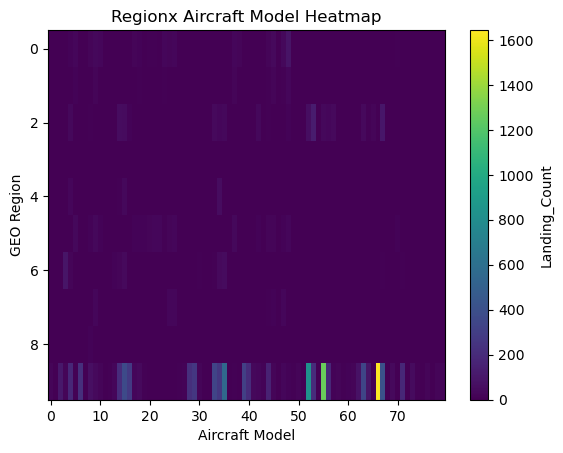

In [241]:
#Heatmap
plt.imshow(region_model,aspect='auto')
plt.colorbar(label="Landing_Count")
plt.xlabel("Aircraft Model")
plt.ylabel("GEO Region")
plt.title("Regionx Aircraft Model Heatmap")
plt.show()

## Weight and Capacity Analysis

In [248]:
#Weight Contribution by Aircraft Model
weight_by_model = (
    data.groupby("Aircraft_Model")["Total_Landed_Weight"]
        .sum()
        .sort_values(ascending=False)
)
weight_by_model

Aircraft_Model
737      54171683938
A320     52070811042
747      51750763868
777      30857703069
757      30545132000
            ...     
MD83          390000
B735          220000
PA-31          81500
35A            15300
C402            6850
Name: Total_Landed_Weight, Length: 80, dtype: int64

In [254]:
#Weight Contribution by Aircraft Manufacturer
weight_by_manufacturer = (
    data.groupby("Aircraft_Manufacturer")["Total_Landed_Weight"]
        .sum()
        .sort_values(ascending=False)
)
weight_by_manufacturer

Aircraft_Manufacturer
Boeing               251817325635
Airbus               104165989444
Bombardier            17039039085
Embraer               13254039099
McDonnell Douglas      6924973922
DeHavilland             202601750
Shorts                   37622000
Beechcraft               30624280
Fairchild                20846000
Cessna                    4775350
Lockheed                  3312000
Swearingen                2484460
Piper                       81500
LearJet                     15300
Name: Total_Landed_Weight, dtype: int64

In [258]:
#Weight Distribution by Body Type(Wide/Narrow/Regional)
weight_by_body = (
    data.groupby("Aircraft_Body_Type")["Total_Landed_Weight"]
        .sum()
        .sort_values(ascending=False)
)
weight_by_body

Aircraft_Body_Type
Narrow Body     209517588965
Wide Body       153394012036
Regional Jet     24961781484
Turbo Prop        5630347340
Name: Total_Landed_Weight, dtype: int64

In [262]:
data.columns

Index(['Operating_Airline', 'Operating_Airline_IATA_Code', 'Published_Airline',
       'Published_Airline_IATA_Code', 'GEO_Summary', 'GEO_Region',
       'Landing_Aircraft_Type', 'Aircraft_Body_Type', 'Aircraft_Manufacturer',
       'Aircraft_Model', 'Aircraft_Version', 'Landing_Count',
       'Total_Landed_Weight', 'Month'],
      dtype='object')

In [274]:
#Average Weight per Landing(True Capacity Proxy)
avg_weight = (
    data.groupby("Aircraft_Model")[["Total_Landed_Weight","Landing_Count"]]
        .sum()
)
avg_weight["Avg Weight Per Landing"] = (
    avg_weight["Total_Landed_Weight"] / avg_weight["Landing_Count"]
)
avg_weight = avg_weight.sort_values("Avg Weight Per Landing",ascending=False)
avg_weight

,Total_Landed_Weight,Landing_Count,Avg Weight Per Landing
Aircraft_Model,,,
A380,2206880874,2563,861053.793991
A388,2844486501,3306,860401.240472
B748,2188785000,3039,720231.984205
B744,5083552258,7979,637116.462965
747,51750763868,81276,636728.725183
...,...,...,...
C-99,4576500,405,11300.000000
B-99,9166900,841,10900.000000
C208,4768500,561,8500.000000


In [278]:
#Weight Contribution by GEO Region
weight_by_region = (
    data.groupby("GEO_Region")["Total_Landed_Weight"]
        .sum()
        .sort_values(ascending=False)
)
weight_by_region

GEO_Region
US                     259439115188
Asia                    71207071043
Europe                  35239066104
Canada                  11329890335
Australia / Oceania      6644545526
Mexico                   6208788296
Middle East              2169578076
Central America          1042255379
South America             221911000
Caribbean                   1508878
Name: Total_Landed_Weight, dtype: int64

### Traffic Composition Breakdown

In [280]:
data.columns

Index(['Operating_Airline', 'Operating_Airline_IATA_Code', 'Published_Airline',
       'Published_Airline_IATA_Code', 'GEO_Summary', 'GEO_Region',
       'Landing_Aircraft_Type', 'Aircraft_Body_Type', 'Aircraft_Manufacturer',
       'Aircraft_Model', 'Aircraft_Version', 'Landing_Count',
       'Total_Landed_Weight', 'Month'],
      dtype='object')

In [286]:
#omposition by Aircraft Body Type
traffic_body = (
    data.groupby("Aircraft_Body_Type")["Landing_Count"]
        .sum()
        .sort_values(ascending=False)
)
traffic_body

Aircraft_Body_Type
Narrow Body     1410304
Regional Jet     409917
Wide Body        315365
Turbo Prop       215903
Name: Landing_Count, dtype: int64

In [292]:
#Composition by Aircraft Model
traffic_model = (
    data.groupby("Aircraft_Model")["Landing_Count"]
        .sum()
        .sort_values(ascending=False)
)
traffic_model

Aircraft_Model
737     404520
A320    365929
A319    166034
757     151547
CRJ     135400
         ...  
B777         3
764          2
B735         2
C402         1
35A          1
Name: Landing_Count, Length: 80, dtype: int64

In [294]:
#Composition by Manufacturer
traffic_manufacturer = (
    data.groupby("Aircraft_Manufacturer")["Landing_Count"]
        .sum()
        .sort_values(ascending=False)
)
traffic_manufacturer

Aircraft_Manufacturer
Boeing               1045008
Airbus                636996
Embraer               313167
Bombardier            303389
McDonnell Douglas      43656
DeHavilland             3281
Beechcraft              2293
Fairchild               1489
Shorts                  1447
Cessna                   562
Swearingen               179
Piper                     12
Lockheed                   9
LearJet                    1
Name: Landing_Count, dtype: int64

In [297]:
# Composition By Airline
traffic_airline = (
    data.groupby("Operating_Airline")["Landing_Count"]
        .sum()
        .sort_values(ascending=False)
)
traffic_airline

Operating_Airline
SkyWest Airlines                    551300
United Airlines                     383684
United Airlines - Pre 07/01/2013    325578
Southwest Airlines                  163882
Virgin America                      153791
                                     ...  
BelAir Airlines                         33
Evergreen International Airlines        31
United Parcel Service Co                27
Miami Air International                 11
Xtra Airways                             1
Name: Landing_Count, Length: 95, dtype: int64

In [299]:
# Composition by GEO Region
traffic_region = (
    data.groupby("GEO_Region")["Landing_Count"]
        .sum()
        .sort_values(ascending=False)
)
traffic_region

GEO_Region
US                     1997194
Asia                    125625
Canada                   97460
Europe                   63283
Mexico                   44219
Australia / Oceania      11880
Central America           7265
Middle East               3871
South America              689
Caribbean                    3
Name: Landing_Count, dtype: int64

### Correlation and Statistical Patterns

In [306]:
data_corr = data[["Landing_Count" , "Total_Landed_Weight"]].corr()
data_corr 

,Landing_Count,Total_Landed_Weight
Landing_Count,1.000000,0.781654
Total_Landed_Weight,0.781654,1.000000


In [314]:
# Correlation after aggregation by aircraft model
model_stats = (
    data.groupby("Aircraft_Model")[["Landing_Count","Total_Landed_Weight"]]
        .sum()
)
model_stats.corr()

,Landing_Count,Total_Landed_Weight
Landing_Count,1.000000,0.835916
Total_Landed_Weight,0.835916,1.000000


In [316]:
# Add AVG Weight Per Landing (true capaciy behavior)
model_stats["Avg_Weight_Per_Landing"] = (
    model_stats["Total_Landed_Weight"] / model_stats["Landing_Count"]
)
model_stats.head()

,Landing_Count,Total_Landed_Weight,Avg_Weight_Per_Landing
Aircraft_Model,,,
1900C,976,15713600,16100.000000
35A,1,15300,15300.000000
717,2699,292600000,108410.522416
727,950,131837000,138775.789474
737,404520,54171683938,133915.959503


In [320]:
model_stats.corr()

,Landing_Count,Total_Landed_Weight,Avg_Weight_Per_Landing
Landing_Count,1.000000,0.835916,-0.156296
Total_Landed_Weight,0.835916,1.000000,0.096927
Avg_Weight_Per_Landing,-0.156296,0.096927,1.000000


In [330]:
# Using ANOVA pattern to Find Weight Diffrences Across Body Types
body_stats = (
    data.groupby("Aircraft_Body_Type")[["Landing_Count","Total_Landed_Weight"]]
        .sum()
)
body_stats["Avg_Weight_Per_Landing"] = (
    body_stats["Total_Landed_Weight"] / body_stats["Landing_Count"]
)
body_stats

,Landing_Count,Total_Landed_Weight,Avg_Weight_Per_Landing
Aircraft_Body_Type,,,
Narrow Body,1410304,209517588965,148562.004337
Regional Jet,409917,24961781484,60894.721331
Turbo Prop,215903,5630347340,26078.133884
Wide Body,315365,153394012036,486401.509476


In [340]:
# Airline Level Satistical Patterns
airline_stats = (
    data.groupby("Operating_Airline")[["Landing_Count","Total_Landed_Weight"]]
        .sum()
)
airline_stats["Avg_Weight_Per_Landing"] = (
    airline_stats["Total_Landed_Weight"] / airline_stats["Landing_Count"]
)
airline_stats.sort_values("Avg_Weight_Per_Landing", ascending=False)

,Landing_Count,Total_Landed_Weight,Avg_Weight_Per_Landing
Operating_Airline,,,
Nippon Cargo Airlines,4274,2907313000,680232.335049
Emirates,3502,2359596133,673785.303541
Cargolux Airlines,312,207792000,666000.000000
Lufthansa German Airlines,9422,6161468087,653944.819253
British Airways,9529,6183113706,648873.303180
...,...,...,...
ExpressJet Airlines,2398,104449470,43556.909925
American Eagle Airlines,7171,295837354,41254.686097
Air Cargo Carriers,1447,37622000,26000.000000


In [346]:
# Region Level Statistical Patterns
region_stats = (
    data.groupby("GEO_Region")[["Landing_Count","Total_Landed_Weight"]]
        .sum()
)
region_stats["Avg_Weight_Per_Landing"] = (
    region_stats["Total_Landed_Weight"] / region_stats["Landing_Count"]
)
region_stats

,Landing_Count,Total_Landed_Weight,Avg_Weight_Per_Landing
GEO_Region,,,
Asia,125625,71207071043,566822.456064
Australia / Oceania,11880,6644545526,559305.178956
Canada,97460,11329890335,116251.696440
Caribbean,3,1508878,502959.333333
Central America,7265,1042255379,143462.543565
Europe,63283,35239066104,556848.855206
Mexico,44219,6208788296,140409.966214
Middle East,3871,2169578076,560469.665719
South America,689,221911000,322076.923077


### Pivot Table Insights

In [357]:
#Fleet Composition Analysis
pivot_airline_body = pd.pivot_table(
    data,
    values="Landing_Count",
    index="Operating_Airline",
    columns="Aircraft_Body_Type",
    aggfunc="sum",
    fill_value=0
)
pivot_airline_body

Aircraft_Body_Type,Narrow Body,Regional Jet,Turbo Prop,Wide Body
Operating_Airline,,,,
ABC Aerolineas S.A. de C.V. dba Interjet,173,0,0,0
ABX Air,864,0,0,4197
ATA Airlines,1381,0,0,9
Aer Lingus,0,0,0,1883
Aeromexico,7296,37,0,0
...,...,...,...,...
WOW Air,10,0,0,594
WestJet Airlines,3681,0,0,0
World Airways,0,0,0,192


In [365]:
#Model Distribution by Region
pivot_region_model = pd.pivot_table(
    data,
    values="Total_Landed_Weight",
    index="GEO_Region",
    columns="Aircraft_Model",
    aggfunc="sum",
    fill_value=0
)
pivot_region_model

Aircraft_Model,1900C,35A,717,727,737,747,757,764,767,777,...,MD-11,MD-80,MD-88,MD-90,MD11,MD83,MD90,PA-31,SA-227,SD3
GEO_Region,,,,,,,,,,,,,,,,,,,,,
Asia,0,0,0,0,2831400,32710279611,0,700000,378860000,18740131111,...,44790060,0,0,0,481500,0,0,0,0,0
Australia / Oceania,0,0,0,0,0,3493716802,0,0,0,1480322000,...,0,0,0,0,0,0,0,0,0,0
Canada,0,0,0,164000,1449271610,630000,28022000,0,160081438,554100,...,0,0,0,0,0,0,0,0,0,0
Caribbean,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Central America,0,0,0,0,24285800,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Europe,0,0,0,0,0,14141403455,0,0,394179108,4190394168,...,303821862,0,0,0,0,0,0,0,0,0
Mexico,0,0,0,11011000,2214616500,0,17846000,0,1600500,0,...,0,8190000,0,0,0,0,0,0,0,0
Middle East,0,0,0,0,0,0,0,0,0,1405437690,...,0,0,0,0,0,0,0,0,0,0
South America,0,0,0,0,0,1332000,0,0,218880000,0,...,0,0,0,0,0,0,0,0,0,0


In [375]:
data.columns

Index(['Operating_Airline', 'Operating_Airline_IATA_Code', 'Published_Airline',
       'Published_Airline_IATA_Code', 'GEO_Summary', 'GEO_Region',
       'Landing_Aircraft_Type', 'Aircraft_Body_Type', 'Aircraft_Manufacturer',
       'Aircraft_Model', 'Aircraft_Version', 'Landing_Count',
       'Total_Landed_Weight', 'Month'],
      dtype='object')

In [379]:
# Adding the column Avg_Weight
data["Avg_Weight"] = data["Total_Landed_Weight"] / data["Landing_Count"]

In [381]:
data.head()

,Operating_Airline,Operating_Airline_IATA_Code,Published_Airline,Published_Airline_IATA_Code,GEO_Summary,GEO_Region,Landing_Aircraft_Type,Aircraft_Body_Type,Aircraft_Manufacturer,Aircraft_Model,Aircraft_Version,Landing_Count,Total_Landed_Weight,Month,Avg_Weight
Activity_Period,,,,,,,,,,,,,,,
2018-09-01,SkyWest Airlines,OO,United Airlines,UA,International,Canada,Passenger,Regional Jet,Bombardier,CRJ2,-,30,1410000,9,47000.000
2018-09-01,Air Canada,AC,Air Canada,AC,International,Canada,Passenger,Narrow Body,Airbus,A320,-,125,17787978,9,142303.824
2018-09-01,Japan Airlines,JL,Japan Airlines,JL,International,Asia,Passenger,Wide Body,Boeing,B773,-,30,16620000,9,554000.000
2018-09-01,"COPA Airlines, Inc.",CM,"COPA Airlines, Inc.",CM,International,Central America,Passenger,Narrow Body,Boeing,B739,-,3,491700,9,163900.000
2018-09-01,Hong Kong Airlines Limited,HX,Hong Kong Airlines Limited,HX,International,Asia,Passenger,Wide Body,Airbus,A359,-,16,7301712,9,456357.000


In [385]:
#Capacity and Weight Behavior by Manufacturer
pivot_mfr_body = pd.pivot_table(
    data,
    values="Avg_Weight",
    index="Aircraft_Manufacturer",
    columns="Aircraft_Body_Type",
    aggfunc="mean",
    fill_value=0
)
pivot_mfr_body

Aircraft_Body_Type,Narrow Body,Regional Jet,Turbo Prop,Wide Body
Aircraft_Manufacturer,,,,
Airbus,143041.078217,0.000000,0.000000,478279.204125
Beechcraft,0.000000,0.000000,12546.907441,0.000000
Boeing,149132.685583,0.000000,0.000000,520913.437395
Bombardier,0.000000,62301.151890,0.000000,0.000000
Cessna,0.000000,0.000000,8443.103448,0.000000
DeHavilland,0.000000,0.000000,61750.000000,0.000000
Embraer,0.000000,75821.128099,25800.000000,0.000000
Fairchild,0.000000,0.000000,14000.000000,0.000000
LearJet,0.000000,15300.000000,0.000000,0.000000


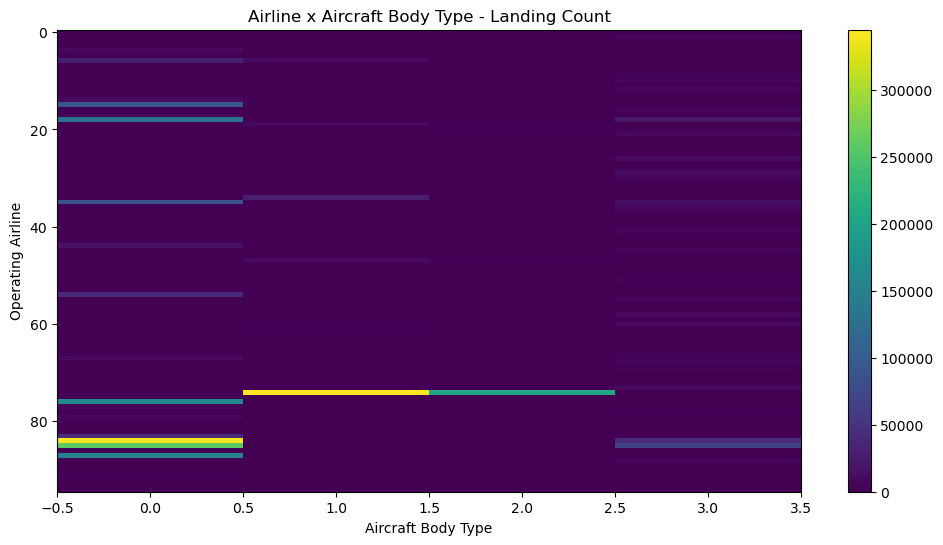

In [387]:
# Fleet mix heatmap
plt.figure(figsize=(12,6))
plt.imshow(pivot_airline_body, aspect="auto")
plt.colorbar()
plt.title("Airline x Aircraft Body Type - Landing Count")
plt.xlabel("Aircraft Body Type")
plt.ylabel("Operating Airline")
plt.show()

### Anomaly Detection

In [394]:
#canonicalize numeric columns
num_landing = [c for c in data.columns if "landing" in c.lower()][0]
num_weight = [c for c in data.columns if "weight" in c.lower()][0]

data[num_landing] = pd.to_numeric(data[num_landing], errors="coerce")
data[num_weight] = pd.to_numeric(data[num_weight], errors="coerce")

In [410]:
data.columns.tolist()

['Operating_Airline',
 'Operating_Airline_IATA_Code',
 'Published_Airline',
 'Published_Airline_IATA_Code',
 'GEO_Summary',
 'GEO_Region',
 'Landing_Aircraft_Type',
 'Aircraft_Body_Type',
 'Aircraft_Manufacturer',
 'Aircraft_Model',
 'Aircraft_Version',
 'Landing_Count',
 'Total_Landed_Weight',
 'Month',
 'Avg_Weight']

In [412]:
[c for c in data.columns if "landing" in c.lower()]
[c for c in data.columns if "weight" in c.lower()]

['Total_Landed_Weight', 'Avg_Weight']

In [432]:
Avg_Weight_Per_Landing = data["Total_Landed_Weight"] / data["Landing_Count"]

In [434]:
data.columns.tolist()

['Operating_Airline',
 'Operating_Airline_IATA_Code',
 'Published_Airline',
 'Published_Airline_IATA_Code',
 'GEO_Summary',
 'GEO_Region',
 'Landing_Aircraft_Type',
 'Aircraft_Body_Type',
 'Aircraft_Manufacturer',
 'Aircraft_Model',
 'Aircraft_Version',
 'Landing_Count',
 'Total_Landed_Weight',
 'Month',
 'Avg_Weight']

In [438]:
#Rule base quick wins (obvious garbage)
#checking for zero or negative(-ve) counts/weights
mask_garbage = (data[num_landing] <= 0) | (data[num_weight] <= 0) | (data["Avg_Weight"] <= 0)
data.loc[mask_garbage, ["Operating_Airline","Aircraft_Model", num_landing, num_weight, "Avg_Weight"]]

,Operating_Airline,Aircraft_Model,Landing_Aircraft_Type,Total_Landed_Weight,Avg_Weight
Activity_Period,,,,,


In [454]:
# Univariate robust detection(IQR & MAD). IQR method for Landing Count and AVG Weight
def iqr_outliers(series, k=1.5):
    q1, q3 = series.quantile([0.25,0.75])
    iqr = q3-q1
    lower, upper = q1-k*iqr, q3 + k*iqr
    return (series < lower) | (series > upper), (lower, upper)

for col in [num_landing, "Avg_Weight",num_weight]:
    mask, bounds = iqr_outliers(data[col])
    (col, "bounds:", bounds, "outliers:", mask.sum())

# Modofiesd Z-Score (uses median absolute deviation)
from statsmodels import robust
def modified_zscore(series):
    med = series.median()
    mad = robust.mad(series)
    if mad == 0:
        return pd.Series([0]*len(series), index=series.index)
    return 0.6745*(series - med)/mad

mz = modified_zscore(data["Avg_Weight"].fillna(0))
data["mz_Avg_Weight"] = mz
"Modifdied z > 3.5:", (data["mz_Avg_Weight"].abs() > 3.5).sum()

('Modifdied z > 3.5:', 0)

In [468]:
data.columns.tolist()

['Operating_Airline',
 'Operating_Airline_IATA_Code',
 'Published_Airline',
 'Published_Airline_IATA_Code',
 'GEO_Summary',
 'GEO_Region',
 'Landing_Aircraft_Type',
 'Aircraft_Body_Type',
 'Aircraft_Manufacturer',
 'Aircraft_Model',
 'Aircraft_Version',
 'Landing_Count',
 'Total_Landed_Weight',
 'Month',
 'Avg_Weight',
 'mz_Avg_Weight']

In [472]:
col = "Avg_Weight"
median = data[col].median()
mad = (data[col].abs() - median).abs().median()
data["anom_score"] = 0.6745 * (data[col] - median) / mad

In [474]:
data["anom_score"].head()

Activity_Period
2018-09-01   -0.834832
2018-09-01   -0.307927
2018-09-01    1.968213
2018-09-01   -0.188528
2018-09-01    1.428375
Name: anom_score, dtype: float64